In [1]:
import pandas as pd

# 1. Đọc dữ liệu gốc
file_path = r'D:\Study\AiTa_Lab_Research\Data_test\PTEN.csv' # Nhớ thay đổi đường dẫn khớp với máy của bạn
df = pd.read_csv(file_path)

print(f"Tổng số biến thể ban đầu: {len(df)}")

# 2. Xóa các dòng không có điểm số thực nghiệm (NaN)
df = df.dropna(subset=['score'])

# 3. Lọc lấy Đột biến sai nghĩa (Missense)
df_missense = df[~df['hgvs_pro'].str.contains('Ter|del|ins|=', na=False)].copy()

print(f"Số biến thể sau khi lọc lấy missense: {len(df_missense)}")

# 4. Tạo hàm gán nhãn với ngưỡng chính xác từ biểu đồ
def assign_label(score):
    if score <= -2.1:
        return 'patho'
    elif score >= -1.1:
        return 'benign'
    else:
        return 'unknown' # Vùng xám trung gian sẽ bị loại bỏ

df_missense['label'] = df_missense['score'].apply(assign_label)

# 5. Lọc bỏ các biến thể 'unknown'
df_clean = df_missense[df_missense['label'] != 'unknown'].copy()

# 6. Giữ lại các cột cần thiết (dùng hgvs_nt)
final_df = df_clean[['hgvs_nt', 'label', 'score']]

# Xuất ra file tạm thời
final_df.to_csv('PTEN_labeled_for_API.csv', index=False)

print(f"Số biến thể sau khi lọc nhãn (Patho/Benign): {len(final_df)}")
print("Phân bố nhãn:")
print(final_df['label'].value_counts())
print("\n5 dòng đầu tiên chuẩn bị cho API:")
print(final_df.head())

Tổng số biến thể ban đầu: 8681
Số biến thể sau khi lọc lấy missense: 7261
Số biến thể sau khi lọc nhãn (Patho/Benign): 6427
Phân bố nhãn:
label
benign    4966
patho     1461
Name: count, dtype: int64

5 dòng đầu tiên chuẩn bị cho API:
                 hgvs_nt   label     score
2    c.1208_1209delinsAA  benign  0.193065
8    c.1208_1209delinsGT   patho -2.736793
14  c.1207_1209delinsTGG   patho -2.459162
17   c.[1207G>A;1209C>G]  benign  0.106511
21   c.1208_1209delinsCT   patho -3.172111


In [2]:
import pandas as pd
import requests
import json
import time

# 1. Đọc dữ liệu từ Cell 1
df = pd.read_csv('PTEN_labeled_for_API.csv')

# 2. Ghép mã Transcript chuẩn của PTEN
df['hgvs_query'] = 'ENST00000371953:' + df['hgvs_nt']
queries = df['hgvs_query'].dropna().unique().tolist()

# 3. Chuẩn bị thông số VEP API
server = "https://rest.ensembl.org"
ext = "/vep/human/hgvs"
headers = {
    "Content-Type": "application/json", 
    "Accept": "application/json"
}

# 4. Gửi request theo lô (batch) 200 đột biến
chunk_size = 200
vep_results = []

print(f"Bắt đầu truy vấn VEP API cho {len(queries)} đột biến PTEN...")

for i in range(0, len(queries), chunk_size):
    chunk = queries[i : i + chunk_size]
    data = {"hgvs_notations": chunk}
    
    response = requests.post(server + ext, headers=headers, data=json.dumps(data))
    
    if not response.ok:
        print(f"Lỗi ở lô {i}: {response.status_code}")
        continue
        
    vep_results.extend(response.json())
    print(f"Đã xử lý {min(i + chunk_size, len(queries))}/{len(queries)}")
    time.sleep(0.2) # Nghỉ 0.2s để tránh bị block IP

# 5. Trích xuất 4 cột tọa độ từ dữ liệu JSON trả về
parsed_data = []
for res in vep_results:
    query_input = res.get('input')
    
    # Lấy thông tin tọa độ
    chrom = 'chr' + str(res.get('seq_region_name'))
    pos = res.get('start')
    
    # Lấy nucleotide Ref/Alt
    allele_string = res.get('allele_string', '')
    if '/' in allele_string:
        ref, alt = allele_string.split('/', 1)
        # Bộ lọc SNV nghiêm ngặt
        if len(ref) == 1 and len(alt) == 1:
            parsed_data.append({
                'hgvs_query': query_input,
                'chrom': chrom,
                'pos': pos,
                'ref': ref,
                'alt': alt
            })

df_parsed = pd.DataFrame(parsed_data)

# 6. Gộp (Merge) lại với file gốc
final_df = pd.merge(df_parsed, df[['hgvs_query', 'label', 'score']], on='hgvs_query', how='inner')

# 7. Cấu trúc lại đúng 5 cột theo yêu cầu + cột score để làm description
final_df = final_df[['chrom', 'pos', 'ref', 'alt', 'label', 'score']].drop_duplicates()

# 8. Lưu bộ Dataset cuối cùng
final_df.to_csv('PTEN_Final_Dataset.csv', index=False)
print("\nĐã hoàn thành! Lưu dữ liệu tại: PTEN_Final_Dataset.csv")
print(final_df.head())

Bắt đầu truy vấn VEP API cho 6427 đột biến PTEN...
Đã xử lý 200/6427
Đã xử lý 400/6427
Đã xử lý 600/6427
Đã xử lý 800/6427
Đã xử lý 1000/6427
Đã xử lý 1200/6427
Đã xử lý 1400/6427
Đã xử lý 1600/6427
Đã xử lý 1800/6427
Đã xử lý 2000/6427
Đã xử lý 2200/6427
Đã xử lý 2400/6427
Đã xử lý 2600/6427
Đã xử lý 2800/6427
Đã xử lý 3000/6427
Đã xử lý 3200/6427
Đã xử lý 3400/6427
Đã xử lý 3600/6427
Đã xử lý 3800/6427
Đã xử lý 4000/6427
Đã xử lý 4200/6427
Đã xử lý 4400/6427
Đã xử lý 4600/6427
Đã xử lý 4800/6427
Đã xử lý 5000/6427
Đã xử lý 5200/6427
Đã xử lý 5400/6427
Đã xử lý 5600/6427
Đã xử lý 5800/6427
Đã xử lý 6000/6427
Đã xử lý 6200/6427
Đã xử lý 6400/6427
Đã xử lý 6427/6427

Đã hoàn thành! Lưu dữ liệu tại: PTEN_Final_Dataset.csv
   chrom       pos ref alt   label     score
0  chr10  87965464   A   G  benign -0.581657
1  chr10  87965465   A   G  benign  0.367969
2  chr10  87965464   A   C  benign  0.228403
3  chr10  87965462   C   G  benign  0.287496
4  chr10  87965461   A   C  benign  0.642758


Đang nạp dữ liệu PTEN...

1. DATASET OVERVIEW (TỔNG QUAN)
Shape (Số dòng, Số cột): (994, 6)

Danh sách các cột (Columns):
['chrom', 'pos', 'ref', 'alt', 'label', 'score']

Kiểu dữ liệu (Data types):
chrom     object
pos        int64
ref       object
alt       object
label     object
score    float64
dtype: object

Số lượng giá trị duy nhất (Unique values):
chrom      1
pos      654
ref        4
alt        4
label      2
score    994
dtype: int64

2. DATA QUALITY (CHẤT LƯỢNG DỮ LIỆU)
Số lượng Missing values ở mỗi cột:
chrom    0
pos      0
ref      0
alt      0
label    0
score    0
dtype: int64

Số lượng dòng trùng lặp (Duplicates): 0

3. UNIVARIATE ANALYSIS (PHÂN TÍCH ĐƠN BIẾN)


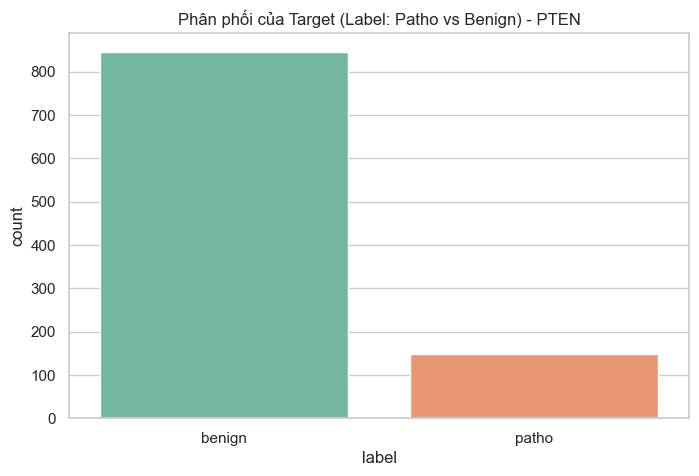

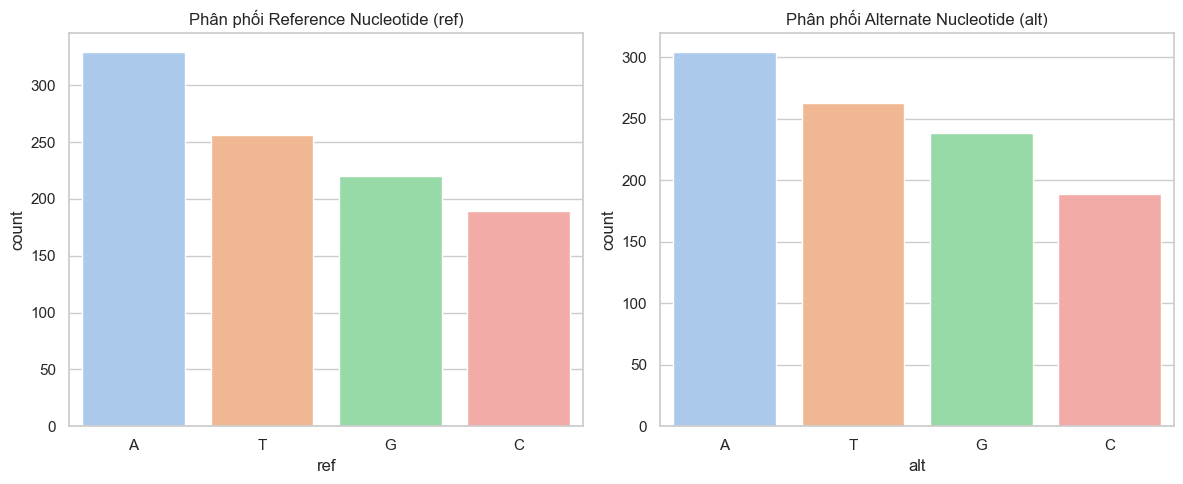

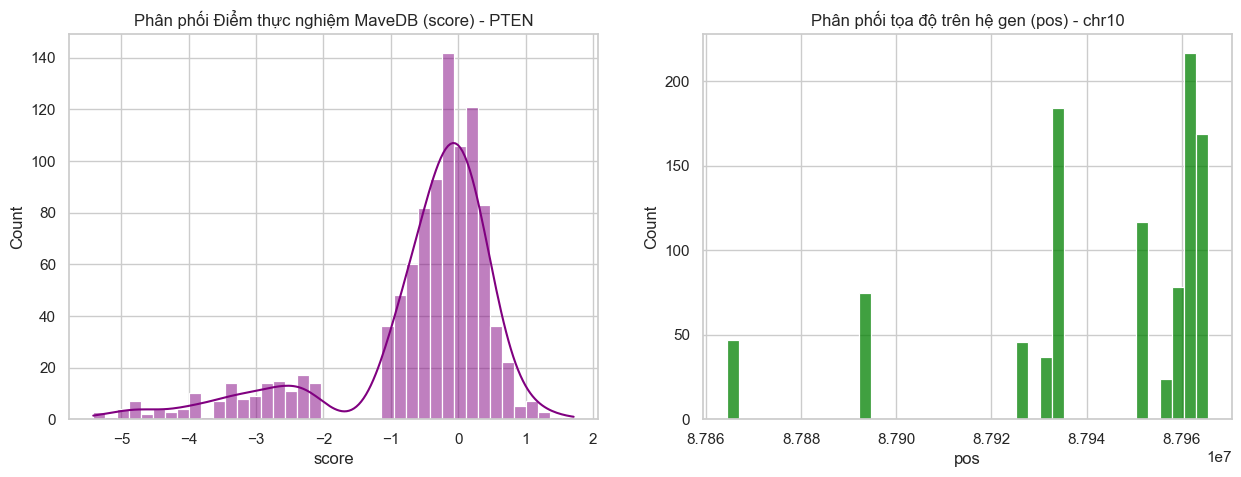


4. OUTLIER ANALYSIS (PHÂN TÍCH NGOẠI LAI TRÊN ĐIỂM SỐ)


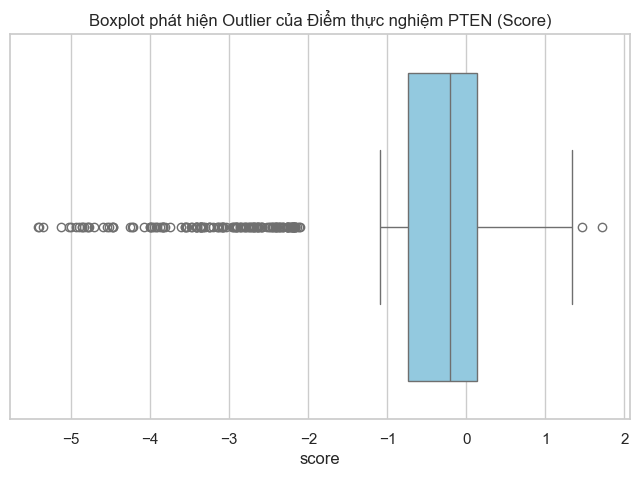

Số lượng Outliers theo IQR (score): 150
Số lượng Outliers theo Z-score > 3 (score): 22

5. BIVARIATE ANALYSIS (PHÂN TÍCH SONG BIẾN)


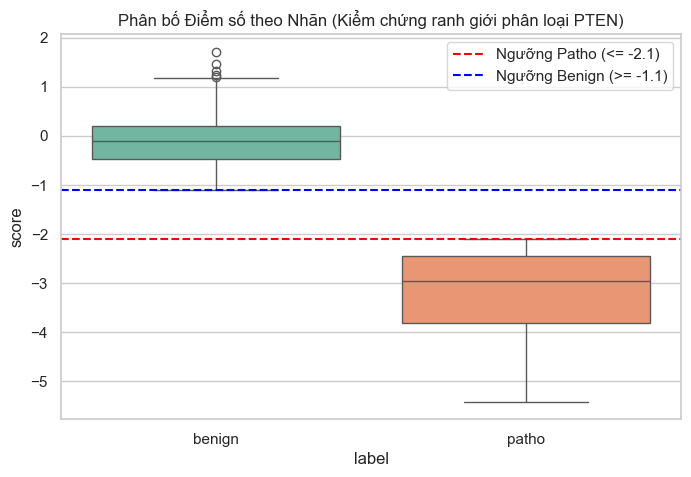

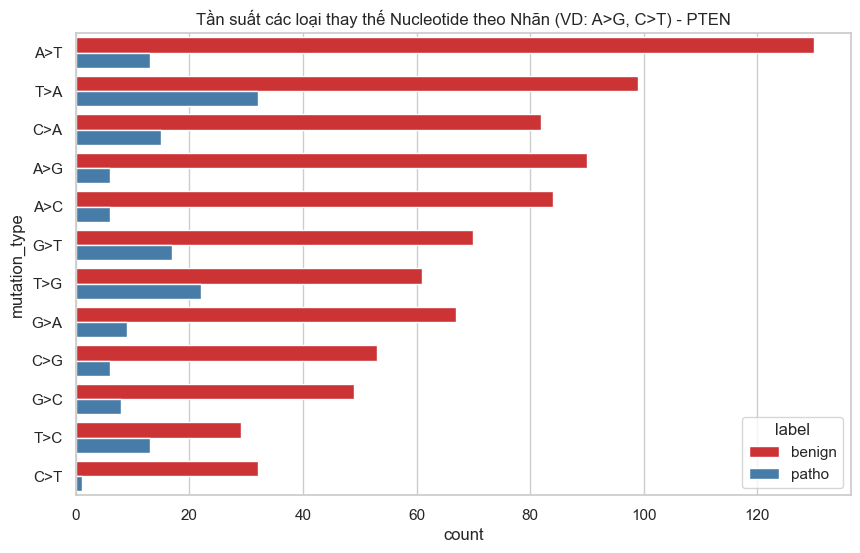


6. CORRELATION ANALYSIS (PHÂN TÍCH TƯƠNG QUAN)


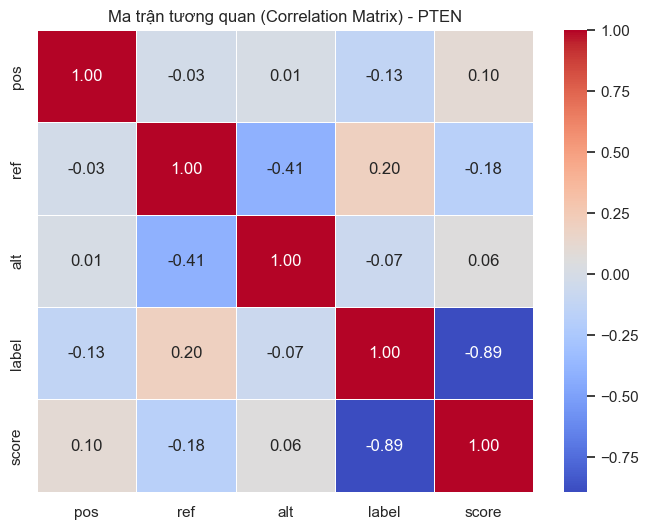


7. THỐNG KÊ TỶ LỆ PATHOGENIC THEO VỊ TRÍ (HOTSPOT ANALYSIS)
- Tỷ lệ đột biến Gây bệnh (Pathogenic) tổng thể của PTEN: 14.89%
- Thống kê số lượng đột biến theo từng vị trí (Phát hiện Hotspot):
pos
87965336    3
87965342    3
87925538    3
87894031    3
87894030    3
87965380    3
87894096    3
87931080    3
87894100    3
87965366    3
Name: count, dtype: int64

8. DATA INSIGHTS (GỢI Ý RÚT RA KẾT LUẬN CHO AITA LAB)

[GÓC NHÌN ĐÁNH GIÁ MODEL CỦA NHÓM]:
- Đặc thù Điểm số âm: Trái ngược với BRCA2 và TP53, PTEN sử dụng dải điểm âm. Boxplot (Phần 5) sẽ cho thấy sự khác biệt về chiều hướng của dữ liệu thực nghiệm, chứng tỏ sự linh hoạt của tập kiểm thử.
- Mật độ đột biến Patho: PTEN thường có tỷ lệ đột biến gây mất chức năng (Pathogenic) khá cao ở một số domain quan trọng. Hãy so sánh tỷ lệ Pathogenic của PTEN với TP53 để xem gen nào nhạy cảm với đột biến sai nghĩa hơn.
- Không gian đánh giá (Benchmarking Space): Cùng với ClinVar_HQ, SwissProt Orthogonal, và ACMG, 3 file (BRCA2, TP53, PTEN) t

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Đang nạp dữ liệu PTEN...")
# Nhớ điều chỉnh lại đường dẫn cho khớp với máy của bạn
df = pd.read_csv(r"PTEN_Final_Dataset.csv")

# Đảm bảo cột pos và score là dạng số
df['pos'] = pd.to_numeric(df['pos'], errors='coerce')
df['score'] = pd.to_numeric(df['score'], errors='coerce')

print("\n" + "="*50)
print("1. DATASET OVERVIEW (TỔNG QUAN)")
print("="*50)
print(f"Shape (Số dòng, Số cột): {df.shape}")
print("\nDanh sách các cột (Columns):")
print(df.columns.tolist())
print("\nKiểu dữ liệu (Data types):")
print(df.dtypes)
print("\nSố lượng giá trị duy nhất (Unique values):")
print(df.nunique())

print("\n" + "="*50)
print("2. DATA QUALITY (CHẤT LƯỢNG DỮ LIỆU)")
print("="*50)
print("Số lượng Missing values ở mỗi cột:")
print(df.isnull().sum())
print(f"\nSố lượng dòng trùng lặp (Duplicates): {df.duplicated().sum()}")

print("\n" + "="*50)
print("3. UNIVARIATE ANALYSIS (PHÂN TÍCH ĐƠN BIẾN)")
print("="*50)
# 3.1 Target Distribution (Phân phối nhãn)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Phân phối của Target (Label: Patho vs Benign) - PTEN')
plt.show()

# 3.2 Categorical Distribution (Phân phối Nucleotide)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='ref', ax=axes[0], palette='pastel', order=['A', 'T', 'G', 'C'])
axes[0].set_title('Phân phối Reference Nucleotide (ref)')

sns.countplot(data=df, x='alt', ax=axes[1], palette='pastel', order=['A', 'T', 'G', 'C'])
axes[1].set_title('Phân phối Alternate Nucleotide (alt)')
plt.tight_layout()
plt.show()

# 3.3 Numerical distribution (Phân phối điểm số thực nghiệm và Tọa độ)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['score'], bins=40, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Phân phối Điểm thực nghiệm MaveDB (score) - PTEN')

sns.histplot(df['pos'], bins=40, kde=False, ax=axes[1], color='green')
axes[1].set_title('Phân phối tọa độ trên hệ gen (pos) - chr10')
plt.show()

print("\n" + "="*50)
print("4. OUTLIER ANALYSIS (PHÂN TÍCH NGOẠI LAI TRÊN ĐIỂM SỐ)")
print("="*50)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['score'], color='skyblue')
plt.title('Boxplot phát hiện Outlier của Điểm thực nghiệm PTEN (Score)')
plt.show()

# Tính IQR & Z-score cho score
Q1 = df['score'].quantile(0.25)
Q3 = df['score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['score'] < lower_bound) | (df['score'] > upper_bound)]
print(f"Số lượng Outliers theo IQR (score): {len(outliers_iqr)}")

z_scores = np.abs(stats.zscore(df['score'].dropna()))
outliers_z = len(np.where(z_scores > 3)[0])
print(f"Số lượng Outliers theo Z-score > 3 (score): {outliers_z}")

print("\n" + "="*50)
print("5. BIVARIATE ANALYSIS (PHÂN TÍCH SONG BIẾN)")
print("="*50)
# Numerical ↔ Categorical (score vs label) -> Kiểm chứng lại ranh giới
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='score', palette='Set2')
plt.axhline(-2.1, color='red', linestyle='--', label='Ngưỡng Patho (<= -2.1)')
plt.axhline(-1.1, color='blue', linestyle='--', label='Ngưỡng Benign (>= -1.1)')
plt.title('Phân bố Điểm số theo Nhãn (Kiểm chứng ranh giới phân loại PTEN)')
plt.legend()
plt.show()

# Categorical ↔ Categorical (Sự thay đổi Ref -> Alt)
plt.figure(figsize=(10, 6))
mutation_types = df['ref'] + ">" + df['alt']
df['mutation_type'] = mutation_types
sns.countplot(data=df, y='mutation_type', hue='label', palette='Set1', order=df['mutation_type'].value_counts().index)
plt.title('Tần suất các loại thay thế Nucleotide theo Nhãn (VD: A>G, C>T) - PTEN')
plt.show()

print("\n" + "="*50)
print("6. CORRELATION ANALYSIS (PHÂN TÍCH TƯƠNG QUAN)")
print("="*50)
# Label Encoding các biến categorical
df_encoded = df[['pos', 'ref', 'alt', 'label', 'score']].copy()
for col in ['ref', 'alt', 'label']:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

corr_matrix = df_encoded.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan (Correlation Matrix) - PTEN')
plt.show()

print("\n" + "="*50)
print("7. THỐNG KÊ TỶ LỆ PATHOGENIC THEO VỊ TRÍ (HOTSPOT ANALYSIS)")
print("="*50)
patho_ratio = (df['label'] == 'patho').mean() * 100
print(f"- Tỷ lệ đột biến Gây bệnh (Pathogenic) tổng thể của PTEN: {patho_ratio:.2f}%")
print("- Thống kê số lượng đột biến theo từng vị trí (Phát hiện Hotspot):")
hotspots = df['pos'].value_counts().head(10)
print(hotspots)

print("\n" + "="*50)
print("8. DATA INSIGHTS (GỢI Ý RÚT RA KẾT LUẬN CHO AITA LAB)")
print("="*50)
print("""
[GÓC NHÌN ĐÁNH GIÁ MODEL CỦA NHÓM]:
- Đặc thù Điểm số âm: Trái ngược với BRCA2 và TP53, PTEN sử dụng dải điểm âm. Boxplot (Phần 5) sẽ cho thấy sự khác biệt về chiều hướng của dữ liệu thực nghiệm, chứng tỏ sự linh hoạt của tập kiểm thử.
- Mật độ đột biến Patho: PTEN thường có tỷ lệ đột biến gây mất chức năng (Pathogenic) khá cao ở một số domain quan trọng. Hãy so sánh tỷ lệ Pathogenic của PTEN với TP53 để xem gen nào nhạy cảm với đột biến sai nghĩa hơn.
- Không gian đánh giá (Benchmarking Space): Cùng với ClinVar_HQ, SwissProt Orthogonal, và ACMG, 3 file (BRCA2, TP53, PTEN) từ ProteinGym/MaveDB này đã hoàn thiện mảnh ghép cực kỳ quan trọng về đánh giá Zero-shot không thiên kiến lâm sàng, giúp củng cố luận điểm của nhóm trong báo cáo.
""")

In [1]:
import pandas as pd

print("Đang nạp dữ liệu PTEN chuẩn...")
# Đọc file PTEN đã được làm sạch và map tọa độ từ bước trước
df = pd.read_csv('PTEN_Final_Dataset.csv')

# Thêm cột định danh gen
df['gene'] = 'PTEN'

# Sắp xếp lại thứ tự đúng 6 cột theo yêu cầu của Lớp Fusion
final_mavedb = df[['chrom', 'pos', 'ref', 'alt', 'label', 'gene']]

# Lưu thành file MaveDB tổng quát dưới dạng parquet
final_mavedb.to_parquet('mavedb.parquet', index=False)

print(f"Hoàn tất! File MaveDB.parquet đã sẵn sàng với {len(final_mavedb)} biến thể.")
print(final_mavedb.head())

Đang nạp dữ liệu PTEN chuẩn...
Hoàn tất! File MaveDB.parquet đã sẵn sàng với 994 biến thể.
   chrom       pos ref alt   label  gene
0  chr10  87965464   A   G  benign  PTEN
1  chr10  87965465   A   G  benign  PTEN
2  chr10  87965464   A   C  benign  PTEN
3  chr10  87965462   C   G  benign  PTEN
4  chr10  87965461   A   C  benign  PTEN
